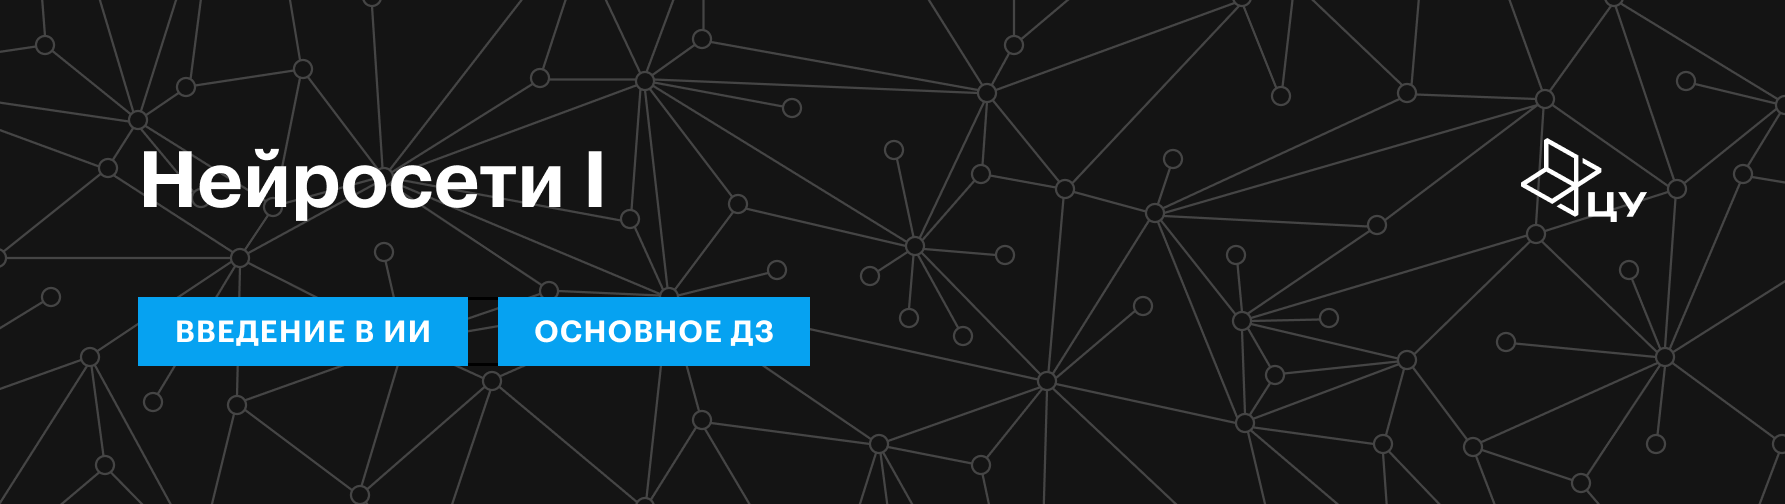

# Домашнее задание по теме «Полносвязные нейросети»

В этом домашнем задании ты продолжишь экспериментировать с простыми полносвязными нейросетями и увидишь, как на качество решения влияют **нормализация**, **функции активации**, **ширина** и **глубина** скрытых слоёв.



>### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.

## Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import pandas as pd

import torch
import torch.nn as nn

import random


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'



In [3]:
# Эта ячейка поможет сделать эксперименты воспроизводимыми
SEED =264

# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Воспроизводимость
torch.use_deterministic_algorithms(True)


In [4]:
# Загружаем данные в среду
!gdown 1EzwSMPRec96B0pte-r3qgiZlFp4igAEy

Downloading...
From: https://drive.google.com/uc?id=1EzwSMPRec96B0pte-r3qgiZlFp4igAEy
To: /content/dataset_zigzag_gap1.csv
100% 30.0k/30.0k [00:00<00:00, 72.0MB/s]


In [5]:
# Загружаем данные в среду
!gdown 1YK8inP21BSKuGK2V85C9VgYpDwDLzSOT

Downloading...
From: https://drive.google.com/uc?id=1YK8inP21BSKuGK2V85C9VgYpDwDLzSOT
To: /content/dataset_small_points.csv
100% 338/338 [00:00<00:00, 1.27MB/s]


In [6]:
# Загружаем данные в среду
!gdown 1Nt1v-oIBVzVLGPCm6hgEZ_GHOzQZG4z6

Downloading...
From: https://drive.google.com/uc?id=1Nt1v-oIBVzVLGPCm6hgEZ_GHOzQZG4z6
To: /content/dataset_four_rings.csv
100% 20.1k/20.1k [00:00<00:00, 52.1MB/s]


---

## Датасеты

1) `dataset_small_points.csv` — датасет с семинара.
2) `dataset_four_rings.csv` — четыре концентрических окружности.
3) `dataset_zigzag_gap1.csv` — зигзагообразная граница с зазором.

Формат: CSV с колонками $x1$, $x2$, $y$, где $y∈{0,1}$.


---

## Вспомогательные функции

Какие-то из этих функций уже знакомы тебе по семинарам, а какие-то ты увидишь впервые. Вспомогательные функции упрощают дизайн экспериментов, поэтому у тебя останется больше сил на размышление, исследование и сами эксперименты.

Так как аналитикам данных часто приходится разбираться в чужом коде, мы намеренно не добавляли описание к функциям.

In [7]:
def load_csv_dataset(path: str):
    df = pd.read_csv(path)
    X = df[["x1", "x2"]].values.astype(np.float32)
    y = df[["y"]].values.astype(np.float32)
    return X, y

def quick_scatter(X, y, title=None):
    x_blue   = X[y[:,0] == 1, 0]
    y_blue   = X[y[:,0] == 1, 1]
    x_orange = X[y[:,0] == 0, 0]
    y_orange = X[y[:,0] == 0, 1]

    plt.figure(figsize=(6.8, 5.2))
    plt.scatter(x_blue, y_blue, s=80, c="tab:blue", label="Класс 1")
    plt.scatter(x_orange, y_orange, s=80, c="tab:orange", label="Класс 0")

    plt.grid(alpha=0.3)
    if title:
        plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()


@torch.no_grad()
def plot_data_and_boundary(
    model,
    X_train_np,
    y_train_np,
    X_mean,
    X_std,
    grid_n=200,
    pad=0.8,
    title="Данные и граница решения"
):
    model.eval()

    x_blue   = X_train_np[y_train_np[:,0] == 1, 0]
    y_blue   = X_train_np[y_train_np[:,0] == 1, 1]
    x_orange = X_train_np[y_train_np[:,0] == 0, 0]
    y_orange = X_train_np[y_train_np[:,0] == 0, 1]

    x_min, x_max = float(X_train_np[:,0].min() - pad), float(X_train_np[:,0].max() + pad)
    y_min, y_max = float(X_train_np[:,1].min() - pad), float(X_train_np[:,1].max() + pad)

    xs = np.linspace(x_min, x_max, grid_n, dtype=np.float32)
    ys = np.linspace(y_min, y_max, grid_n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.stack([Xg.ravel(), Yg.ravel()], axis=1)
    grid_t = torch.tensor(grid).to(device)

    grid_tn = (grid_t - X_mean) / X_std

    logits = model(grid_tn).reshape(-1)
    probs = torch.sigmoid(logits).reshape(grid_n, grid_n).cpu().numpy()

    fig, ax = plt.subplots(figsize=(9.5, 6.5))
    cf = ax.contourf(Xg, Yg, probs, levels=30, alpha=0.35)
    plt.colorbar(cf, ax=ax, label="P(class=1)")

    ax.contour(Xg, Yg, probs, levels=[0.5], linewidths=2)

    ax.scatter(x_blue, y_blue, s=70, c="tab:blue", label="Класс 1")
    ax.scatter(x_orange, y_orange, s=70, c="tab:orange", label="Класс 0")

    ax.grid(True, alpha=0.3)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [8]:

@torch.no_grad()
def compute_metrics(model, Xn, y, criterion):
    model.eval()
    probs = model(Xn)                    # (N,1)
    loss = criterion(probs, y).item()
    preds = (probs >= 0.5).float()
    acc = (preds.eq(y)).float().mean().item()
    return loss, acc

def make_train_step(model, Xn, y, criterion, optimizer):
    def train_step():
        model.train()
        optimizer.zero_grad()
        probs = model(Xn)
        loss = criterion(probs, y)
        loss.backward()
        optimizer.step()
        return compute_metrics(model, Xn, y, criterion)
    return train_step


In [9]:
def print_model_summary_and_weights(model):
    print("=== Архитектура модели ===")
    print(model)

    print("\n=== Параметры (веса и смещения) ===")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            W = module.weight.detach().cpu().numpy()
            b = module.bias.detach().cpu().numpy()
            print(f"\n[{name}] Linear(in={module.in_features}, out={module.out_features})")
            print("W =")
            print(np.array2string(W, precision=4, suppress_small=True))
            print("b =")
            print(np.array2string(b, precision=4, suppress_small=True))

---

## Задание 1 [0,5 балла]

Напиши код, считывающий данные из датасетов **[0,25 балла]**.

Выведи данные при помощи функции `plot_data_and_boundary` **[0,25 балла]**.


/tmp/ipykernel_345/1724833194.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  grid_tn = (grid_t - X_mean) / X_std


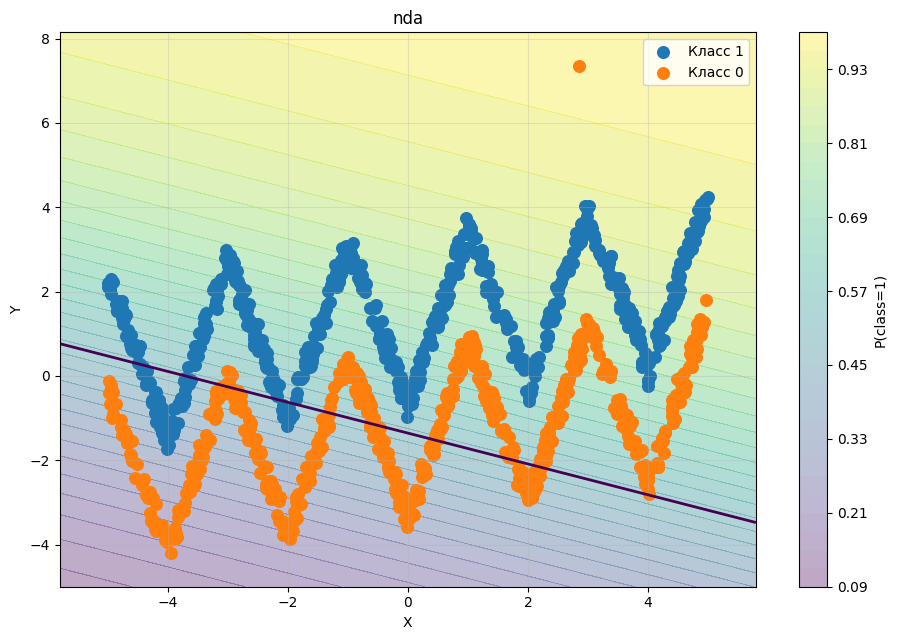

/tmp/ipykernel_345/1724833194.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  grid_tn = (grid_t - X_mean) / X_std


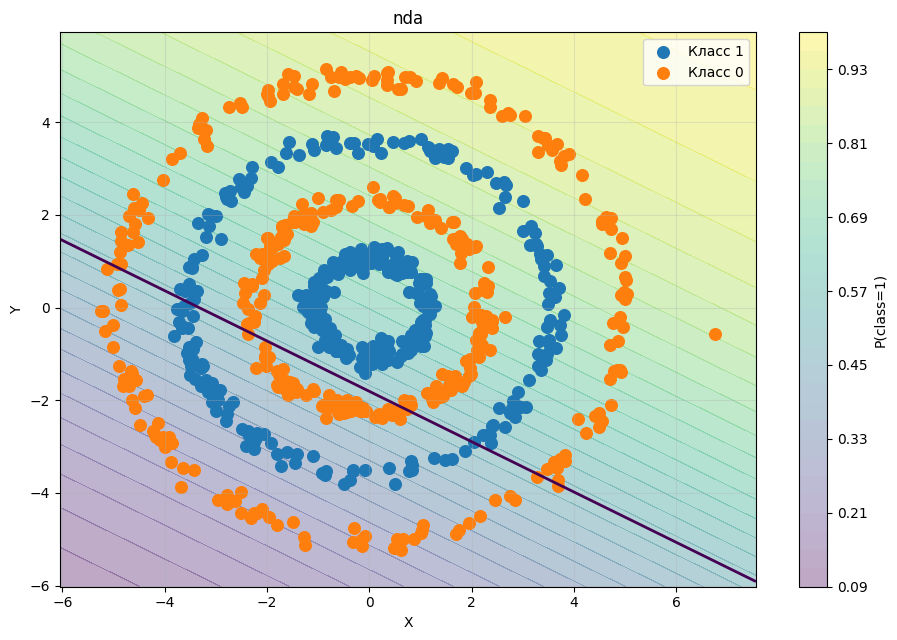

/tmp/ipykernel_345/1724833194.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  grid_tn = (grid_t - X_mean) / X_std


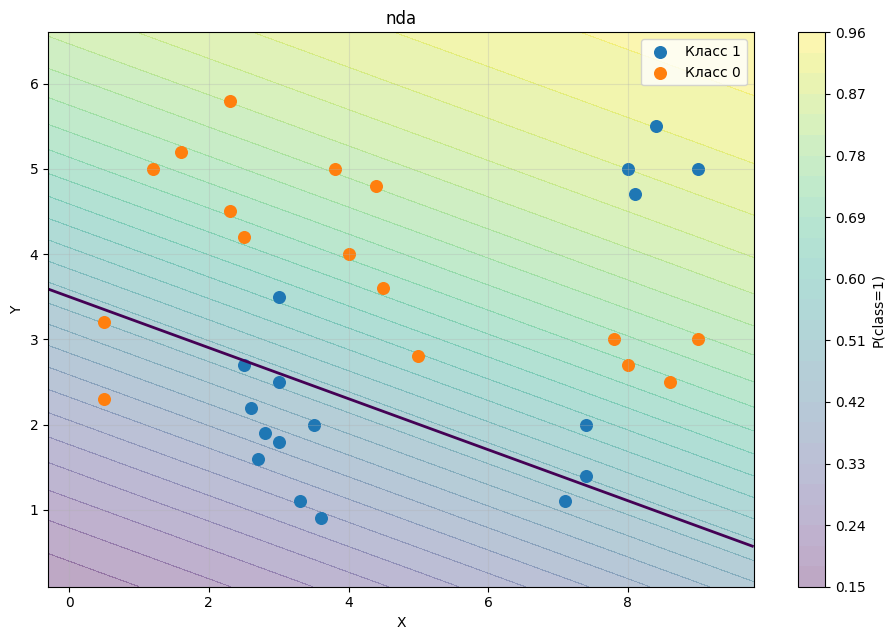

In [10]:
model = torch.nn.Linear(2,1)


def show_dataset(path):
  X, y = load_csv_dataset(path)
  plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")
show_dataset("/content/dataset_zigzag_gap1.csv")
show_dataset("/content/dataset_four_rings.csv")
show_dataset("/content/dataset_small_points.csv")

---

## Задание 2 [1,5 балла]

На семинаре мы работали с простыми нейронными сетями и пытались интерпретировать их поведение. Продолжим эксперименты.

Твоя задача.

1) Создать нейросеть с **двумя скрытыми слоями** и функцией активации $\sigma(x) = tanh(5 \cdot x)$ **[0,5 балла]**.
2) Обучить нейросеть на **ненормализованных** данных (лучше взять $BCEWithLogitsLoss()$ в качестве функционала ошибки) и вывести поле вероятностей при помощи функции `plot_data_and_boundary` **[0,5 балла]**.
3) Оценить, хорошо ли обучилась нейросеть **[0,1 балла]**.
4) Выдвинуть две гипотезы, почему так могло произойти **[0,4 балла]**.

**Датасет:** `dataset_small_points.csv`.

(0.7478492856025696, 0.27272728085517883)
(0.4394347667694092, 0.7878788113594055)


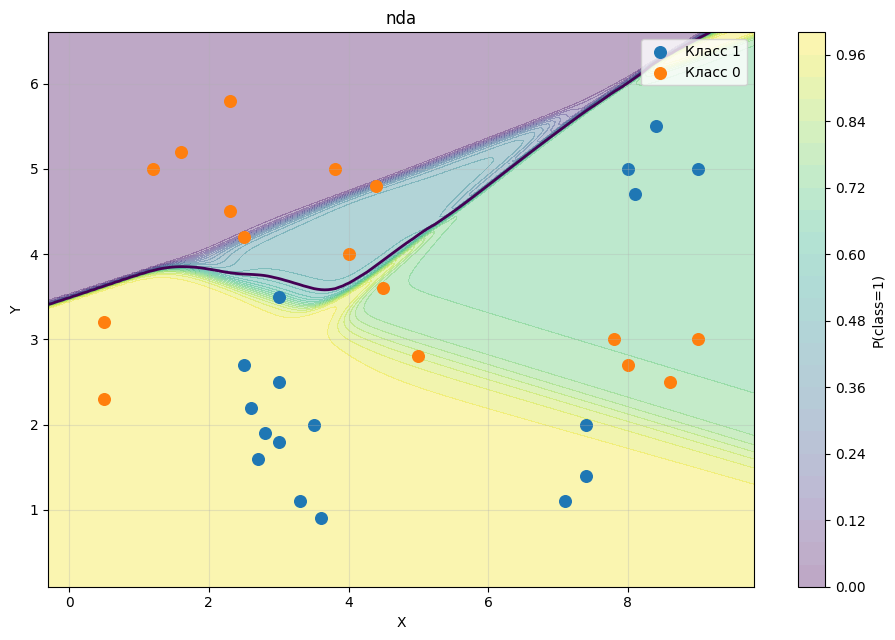

=== Архитектура модели ===
Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): TanhK()
  (2): Linear(in_features=8, out_features=8, bias=True)
  (3): TanhK()
  (4): Linear(in_features=8, out_features=1, bias=True)
)

=== Параметры (веса и смещения) ===

[0] Linear(in=2, out=8)
W =
[[ 0.7068  0.1485]
 [-0.3526 -0.7578]
 [-0.9558  0.5464]
 [ 0.2168  0.528 ]
 [-0.2864 -0.0506]
 [-0.3027 -0.6919]
 [ 1.9813 -1.6471]
 [-0.937   1.6039]]
b =
[ 0.4188 -0.033  -2.3043  0.4169 -0.5378  0.5642  0.7169 -1.9302]

[2] Linear(in=8, out=8)
W =
[[-0.191   0.2552  0.5077  0.1632 -0.1254  0.0595 -0.1485  1.1355]
 [ 0.0567 -0.2797 -0.0398  0.3113  0.1305 -0.1386  0.0609  0.2374]
 [ 0.0806 -0.1122  0.0776 -0.0522 -0.3413 -0.0202 -0.6031 -0.8507]
 [-0.0572 -0.0809  0.4395 -0.1126 -0.4312  0.068  -0.4993  0.7021]
 [ 0.0775 -0.4664  0.5038  0.2985 -0.0008  0.0307 -0.8984  0.4694]
 [ 0.3855 -0.5062 -0.0774 -0.0468  0.0377  0.1197 -0.0873  0.0511]
 [ 0.3319 -0.2235 -0.7014 -0.1587  0.0879

In [11]:
X, y = load_csv_dataset("dataset_small_points.csv")

class TanhK(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.k = k
    def forward(self, x):
        return torch.tanh(self.k * x)

model = nn.Sequential(
    nn.Linear(2, 8),
    TanhK(5),
    nn.Linear(8, 8),
    TanhK(5),
    nn.Linear(8, 1)
).to(device)

X = torch.tensor(X).to(device)
y = torch.tensor(y).to(device)

# preds = model(X)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

# k = criterion(preds, y)
# print(k)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

print_model_summary_and_weights(model)

Тут что-то явно очень странное, вроде есть что-то, но оно явно за 10к эпох толком не обучилась. Наверное нужна нормализация данных или поработать с параметром функции активации.

## Задание 3 [2 балла]

Проблема обучения может быть связана с неправильно подобранной функцией активации. Выясни, так ли это.

1. Обучи нейросеть с функциями активации $Tanh, SiLU$ и $ReLU$. Помогает ли какая-то из них лучше решать задачу с ненормализованными данными?  **[0,5 балла]**.
2. Поэкспериментируй с функциями активации вида $Tanh(kx)$. Зависит ли качество обучения от параметра $k$? **[0,5 балла]**.
3. Поэкспериментируй с функциями активации вида $ReLU(kx)$. Зависит ли качество обучения от параметра $k$? **[0,5 балла]**.
4. Выдвинь гипотезу, почему одни функции активации хорошо работают с ненормализованными данными, а другие нет. **[0,5 балла]**.




(0.6872153878211975, 0.4848484992980957)
(0.475028932094574, 0.7575757503509521)


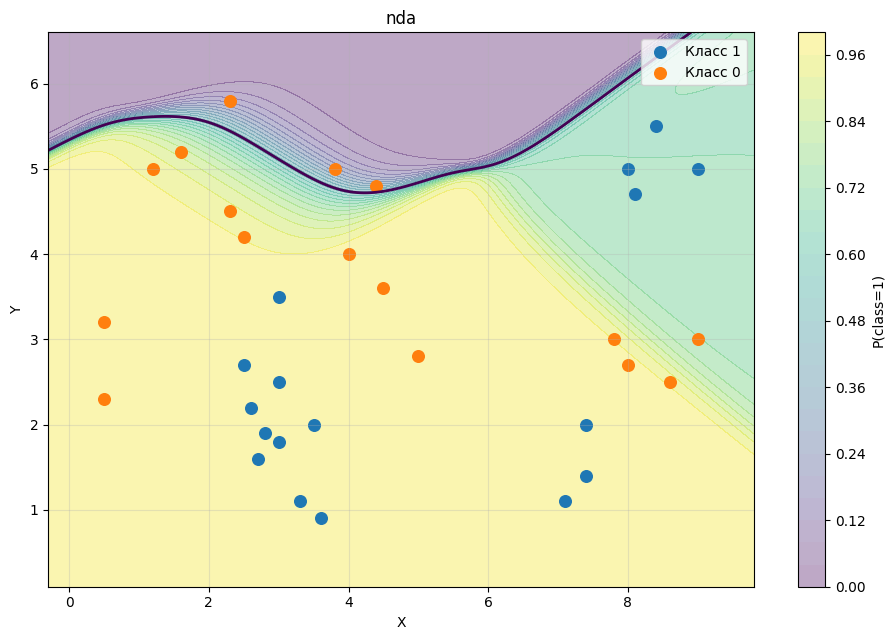

=== Архитектура модели ===
Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): TanhK()
  (2): Linear(in_features=8, out_features=8, bias=True)
  (3): TanhK()
  (4): Linear(in_features=8, out_features=1, bias=True)
)

=== Параметры (веса и смещения) ===

[0] Linear(in=2, out=8)
W =
[[-0.2711 -0.5845]
 [ 1.3361 -1.1414]
 [ 1.326   0.9358]
 [-0.6355 -0.6538]
 [ 1.221  -1.4983]
 [-1.5077  1.4177]
 [ 0.67    0.5549]
 [-0.988   0.3731]]
b =
[-0.1767  4.0662 -1.6993  0.3354  4.6067 -0.9284 -0.5342  0.1174]

[2] Linear(in=8, out=8)
W =
[[ 0.0026  1.2054 -0.1002 -0.6231 -0.4874  0.034   0.3034 -0.5542]
 [-0.3437 -0.384   1.0058  0.0348 -0.2406 -0.0556 -0.0803 -0.2989]
 [-0.0578 -0.3223  0.0706 -0.2933 -0.8664  1.3728 -0.1832 -0.0239]
 [ 0.5099  0.7438 -0.5819  0.4946  1.1631 -1.4548 -0.384  -0.452 ]
 [ 0.2866  0.2521 -0.1222 -0.2083  0.3586  0.2224 -0.3127 -0.1006]
 [ 0.5115  0.728   0.2038  0.1895  1.0658 -0.599  -0.3626 -0.2764]
 [-0.0789  0.249  -0.0888  0.2058  0.0786

In [12]:
X, y = load_csv_dataset("dataset_small_points.csv")

class TanhK(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.k = k
    def forward(self, x):
        return torch.tanh(self.k * x)

model = nn.Sequential(
    nn.Linear(2, 8),
    TanhK(2),
    nn.Linear(8, 8),
    TanhK(2),
    nn.Linear(8, 1)
).to(device)

X = torch.tensor(X).to(device)
y = torch.tensor(y).to(device)

# preds = model(X)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

# k = criterion(preds, y)
# print(k)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

print_model_summary_and_weights(model)

Если поставить k=15, то картинка модели станет очень странной, но на удивление оно обучено практически идеально, что может свидетельствовать о переобучении. Если поставить k=2, модель вообще не обучится.

(35.27766799926758, 0.5151515007019043)
(0.6926878690719604, 0.4848484992980957)


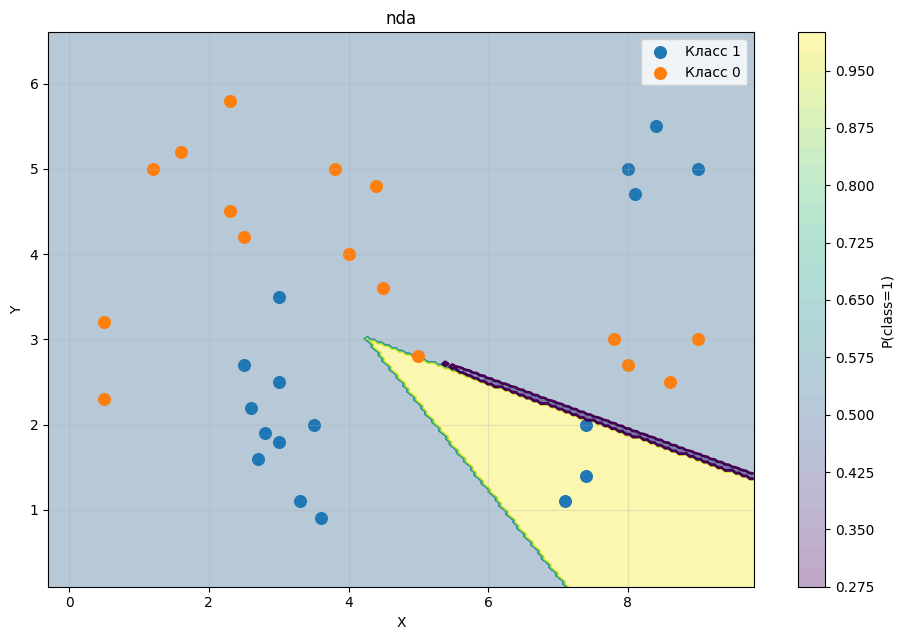

=== Архитектура модели ===
Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLUK()
  (2): Linear(in_features=8, out_features=8, bias=True)
  (3): ReLUK()
  (4): Linear(in_features=8, out_features=1, bias=True)
)

=== Параметры (веса и смещения) ===

[0] Linear(in=2, out=8)
W =
[[   -4.829     -7.0782]
 [   -2.0437    -3.691 ]
 [   -4.9159    -7.1325]
 [   -0.3842     0.0358]
 [-1459.7354  -763.5289]
 [   -3.8585    -6.0463]
 [  -91.669    -48.6027]
 [   -0.1179    -0.446 ]]
b =
[  -2.1685   -0.5219   -1.0904   -0.6936 -289.5199   -1.2732  -18.626
   -0.3801]

[2] Linear(in=8, out=8)
W =
[[   -0.1643    -0.2904    -0.3515    -0.147     -0.1772     0.3448
     -0.0548     0.1872]
 [    0.0301     0.132     -0.3372    -0.0597    -0.0442    -0.2667
     -0.195     -0.0259]
 [   -0.8326    -1.4081    -0.9459     0.1665    -2.2492    -2.5735
     -0.4098    -0.2836]
 [   -0.2965    -0.5871    -0.1698     0.2299    -0.5753    -0.3542
      0.1652     0.2636]
 [    0

In [13]:
X, y = load_csv_dataset("dataset_small_points.csv")

class ReLUK(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.k = k
    def forward(self, x):
        return torch.relu(self.k * x)

model = nn.Sequential(
    nn.Linear(2, 8),
    ReLUK(15),
    nn.Linear(8, 8),
    ReLUK(15),
    nn.Linear(8, 1)
).to(device)

X = torch.tensor(X).to(device)
y = torch.tensor(y).to(device)

# preds = model(X)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

# k = criterion(preds, y)
# print(k)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

print_model_summary_and_weights(model)

У relu = 2 обучение толком отсутствует, при k = 5 вообще все одинаковым нарисовало, и при k=15 плоскость просто порезало, опять плохо.

(0.7225220203399658, 0.4848484992980957)
(0.0005449065938591957, 1.0)


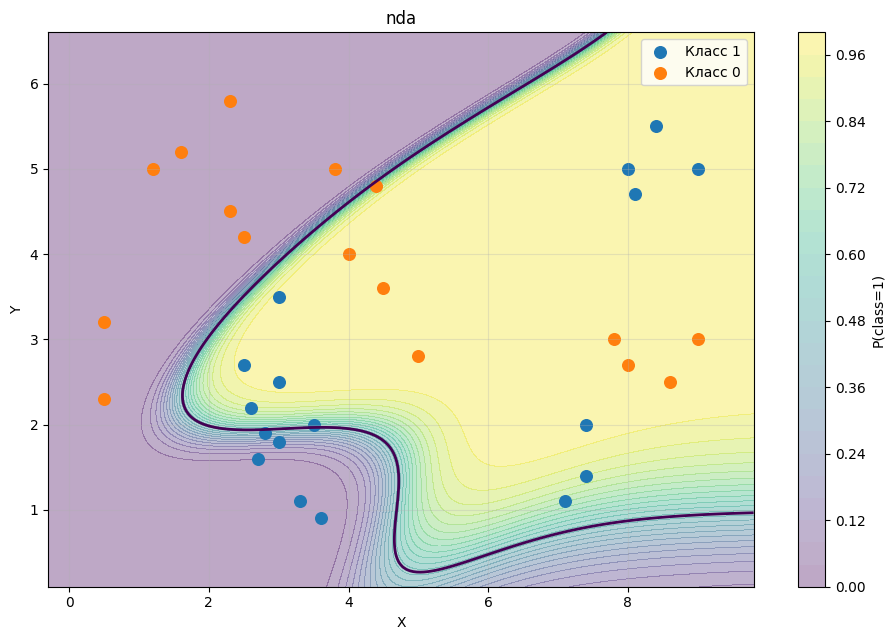

=== Архитектура модели ===
Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): SiLU()
  (2): Linear(in_features=8, out_features=8, bias=True)
  (3): SiLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)

=== Параметры (веса и смещения) ===

[0] Linear(in=2, out=8)
W =
[[ 1.3017 -0.8011]
 [-2.2467  1.9322]
 [ 0.2441 -1.1064]
 [ 0.3613  1.8367]
 [-0.5952 -0.1685]
 [ 2.1342 -2.0792]
 [-0.4205  1.9094]
 [ 0.885  -2.2177]]
b =
[ 0.2561 -0.886   1.2386 -4.7362  0.0954 -2.0035 -2.34    0.4405]

[2] Linear(in=8, out=8)
W =
[[-0.4311  1.9841  0.5301  1.1067  0.9975 -1.7661  1.1466  0.642 ]
 [ 0.4223  0.2052 -0.9884  2.5725  0.949  -0.2692 -1.5733 -1.2362]
 [-1.8803  0.0173  0.222   2.8478 -0.6408  0.7751  1.1997  0.2138]
 [-0.4425 -0.3991  0.1413 -0.4442 -0.23    0.0563 -0.1584  0.4904]
 [-0.2209 -0.3903 -0.3916  0.3321 -0.2093  0.3456 -0.8545 -0.7245]
 [-0.3321  1.5291  0.2004  0.9061  0.8436 -1.4737  0.7964  0.3313]
 [-0.6661  0.6514 -0.235  -0.5669 -0.0402  

In [14]:
X, y = load_csv_dataset("dataset_small_points.csv")

model = nn.Sequential(
    nn.Linear(2, 8),
    nn.SiLU(),
    nn.Linear(8, 8),
    nn.SiLU(),
    nn.Linear(8, 1)
).to(device)

X = torch.tensor(X).to(device)
y = torch.tensor(y).to(device)

# preds = model(X)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

# k = criterion(preds, y)
# print(k)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

print_model_summary_and_weights(model)

Тестируя SiLU мы  видим тоже более-менее линию, но она более прямая, ошибок, видимо, допущено чуть больше. Наверное стоит данные нормализовать, будет что-то получше

---

## Задание 4 [3 балла]

Теперь возьми датасет `dataset_four_rings.csv`, нормализуй данные и проведи несколько экспериментов, сравнив, на что влияют различные параметры в архитектуре нейросетей.

**Эксперимент 1 [1 балл]**: попробуй разные активации ($ReLU$, $SiLU$, $Tanh$) при количестве нейронов на скрытых слоях $<=10$ и числом скрытых слоёв $=2$.

**Эксперимент 2 [1 балл]**: выбери функцию активации и поэкспериментируй с количеством нейронов (хороший вариант — рассмотреть 2 случая $<10$, 2 случая $>10$), сравни с экспериментом 1.

**Эксперимент 3 [1 балл]**: поэкспериментируй с глубиной нейросети (например 1, 3, 5 слоёв). Верно ли, что глубокая нейросеть позволит уменьшить число нейронов на первом слое, при этом не потеряв в качестве? Почему?


In [15]:
X, y = load_csv_dataset("dataset_four_rings.csv")

X[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

X = torch.tensor(X).to(device)
y = torch.tensor(y).to(device)



(1.4994559288024902, 0.38576778769493103)
(0.00017135143571067601, 1.0)


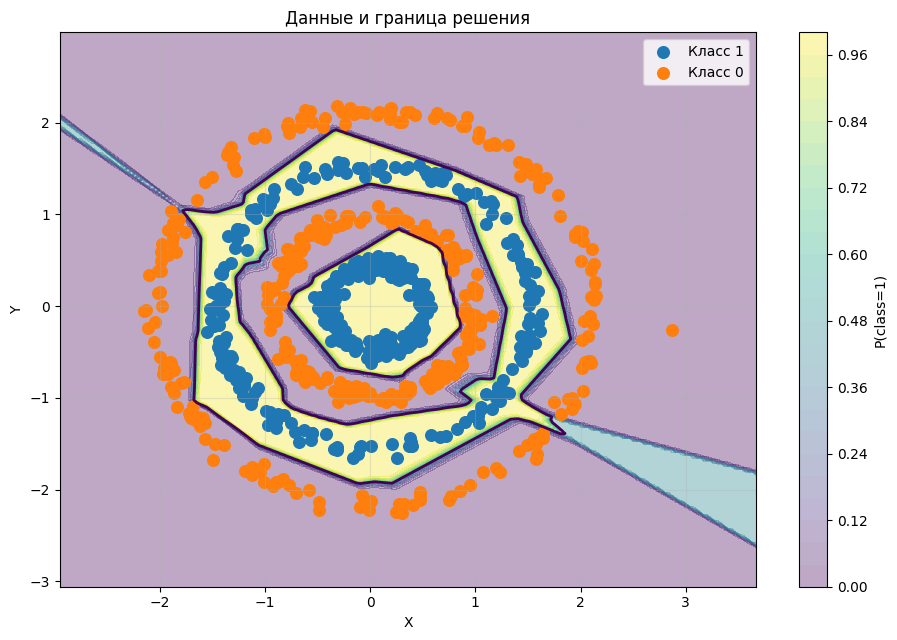

In [16]:
model = nn.Sequential(
    nn.Linear(2, 10),
    ReLUK(5),
    nn.Linear(10, 10),
    ReLUK(5),
    nn.Linear(10, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

С релу вообще все плохо с любым

(0.6912297010421753, 0.6666666865348816)
(0.001910526305437088, 1.0)


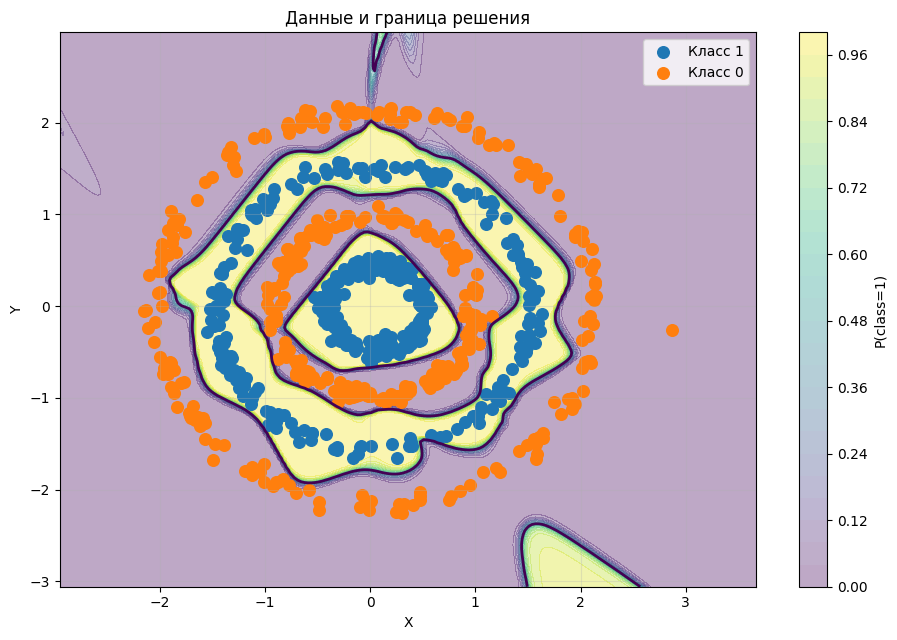

In [17]:
model = nn.Sequential(
    nn.Linear(2, 10),
    TanhK(5),
    nn.Linear(10, 10),
    TanhK(5),
    nn.Linear(10, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

На тангенсе с 5 полчилось обучить, но пространство слишком порезано, как-то слишком переобучено

(0.6935673356056213, 0.5006242394447327)
(0.0013597109355032444, 1.0)


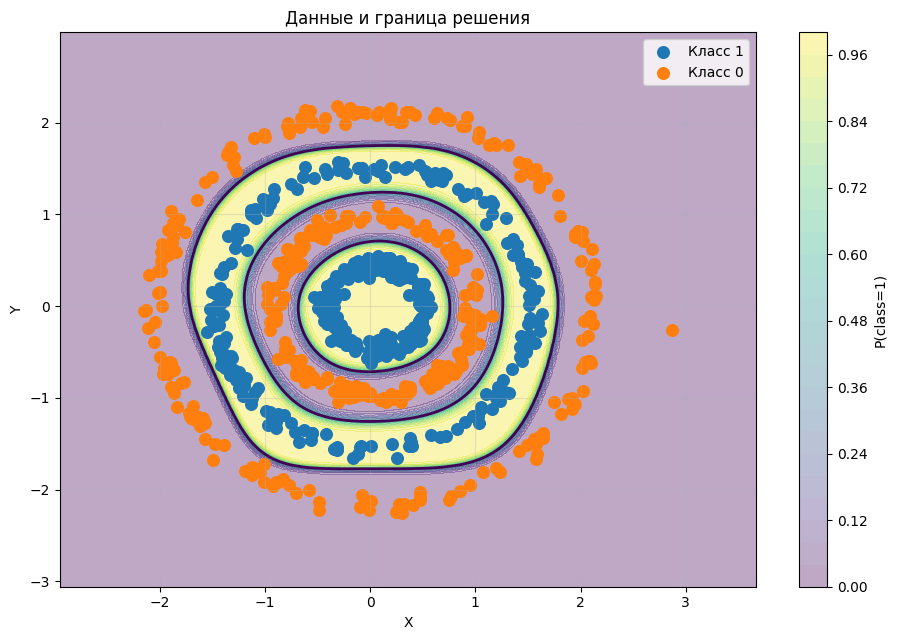

In [18]:
model = nn.Sequential(
    nn.Linear(2, 10),
    nn.SiLU(),
    nn.Linear(10, 10),
    nn.SiLU(),
    nn.Linear(10, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

с SiLU получилось обучить нормально модель.

(0.7003865838050842, 0.5006242394447327)
(0.3275164067745209, 0.8938826322555542)


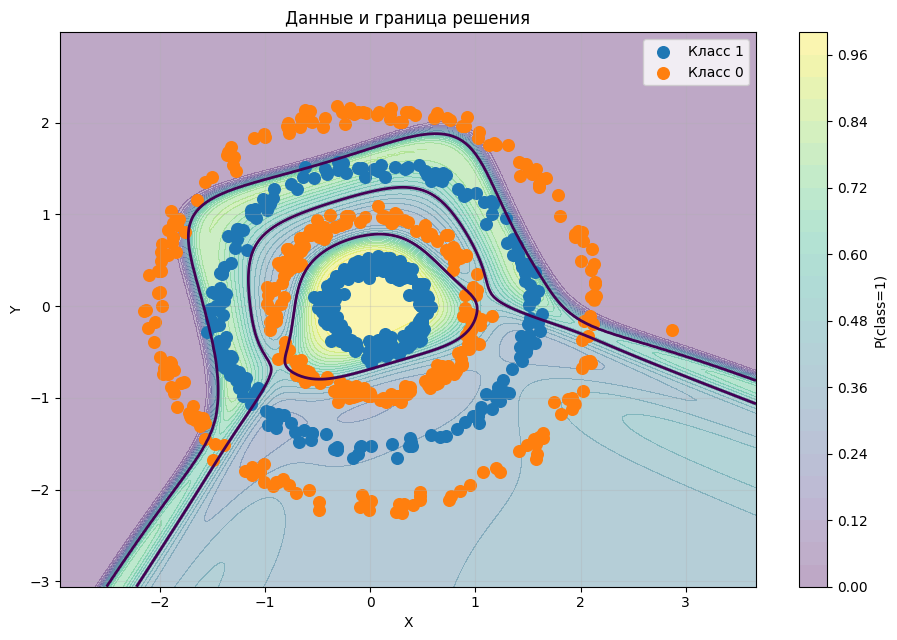

In [21]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.SiLU(),
    nn.Linear(4, 4),
    nn.SiLU(),
    nn.Linear(4, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

(0.7152539491653442, 0.44569289684295654)
(0.0038891879376024008, 1.0)


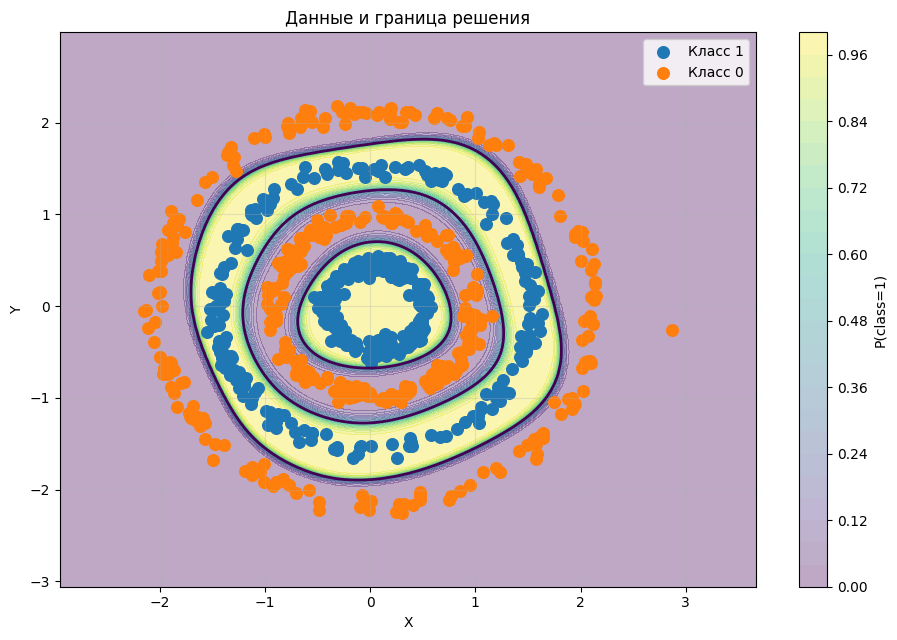

In [27]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.SiLU(),
    nn.Linear(8, 8),
    nn.SiLU(),
    nn.Linear(8, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

(0.6948066353797913, 0.5006242394447327)
(0.0007578618824481964, 1.0)


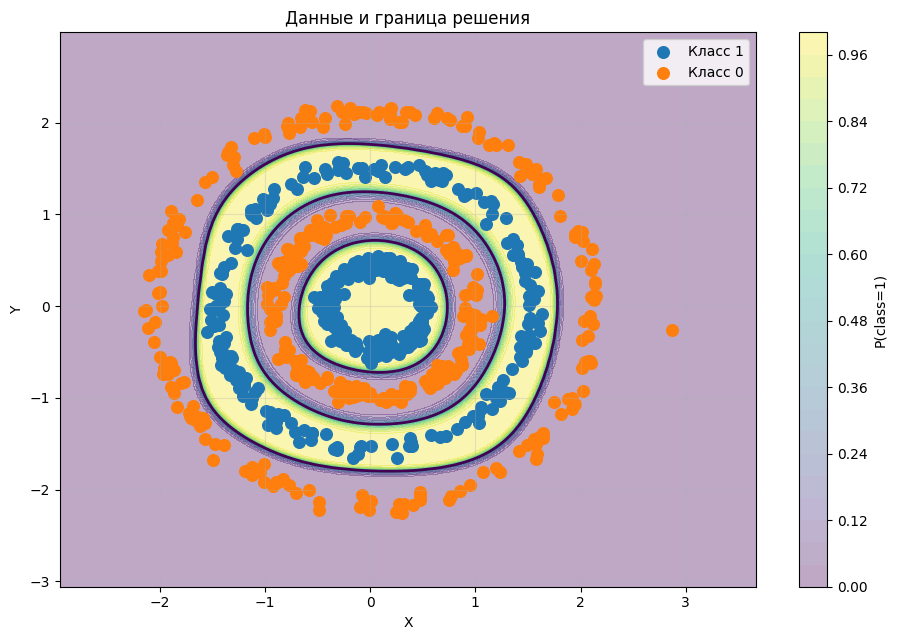

In [22]:
model = nn.Sequential(
    nn.Linear(2, 20),
    nn.SiLU(),
    nn.Linear(20, 20),
    nn.SiLU(),
    nn.Linear(20, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

(0.698914110660553, 0.5006242394447327)
(0.0010726791806519032, 1.0)


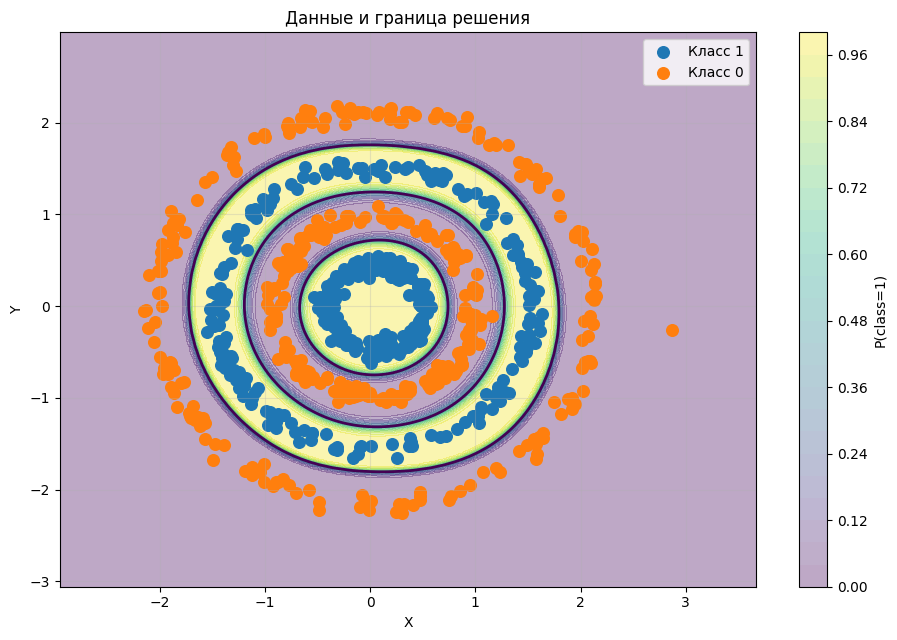

In [23]:
model = nn.Sequential(
    nn.Linear(2, 50),
    nn.SiLU(),
    nn.Linear(50, 50),
    nn.SiLU(),
    nn.Linear(50, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

Увеличение колва нейронов увеличивает качество обучения. При 4 нейронах модель не обучилась, при 8 обучилась, но чуть меньше, чем модель на 20 и 50 параметров.

(0.7015165090560913, 0.5006242394447327)
(0.5842255353927612, 0.5992509126663208)


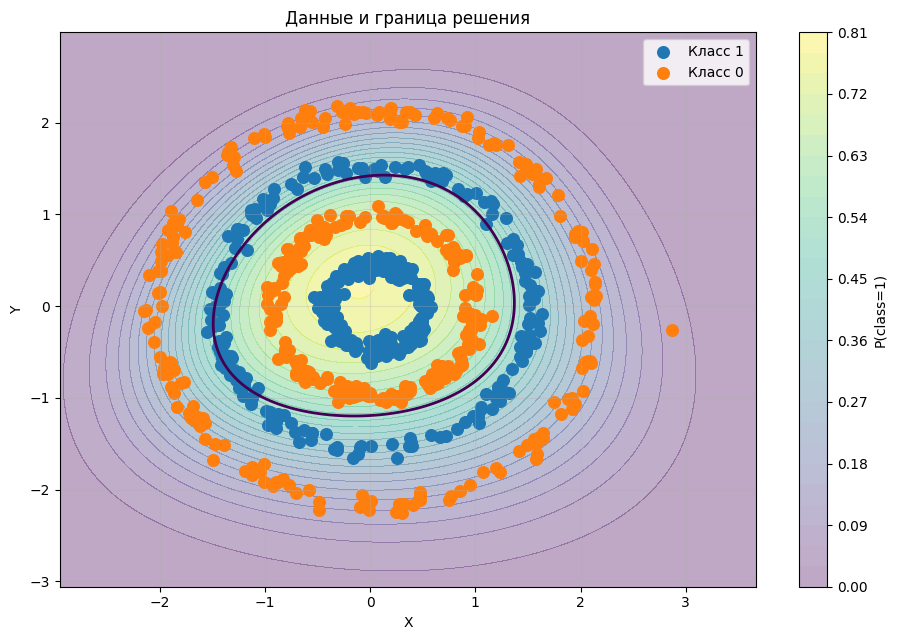

In [28]:
model = nn.Sequential(
    nn.Linear(2, 200),
    nn.SiLU(),
    nn.Linear(200, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

(0.6968216300010681, 0.5006242394447327)
(0.00025105878012254834, 1.0)


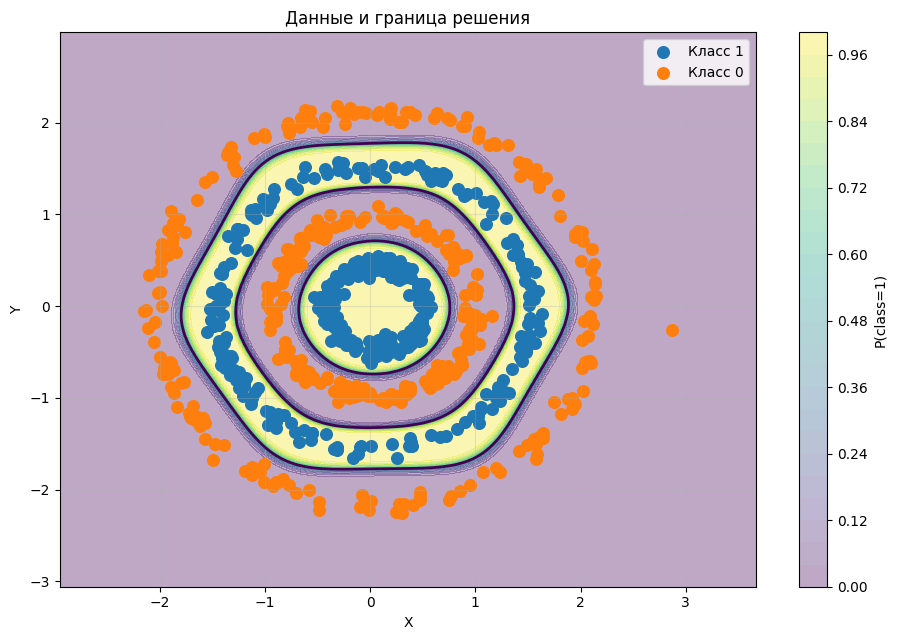

In [29]:
model = nn.Sequential(
    nn.Linear(2, 6),
    nn.SiLU(),
    nn.Linear(6, 6),
    nn.SiLU(),
    nn.Linear(6, 6),
    nn.SiLU(),
    nn.Linear(6, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

(0.6971637606620789, 0.5006242394447327)
(7.252096111187711e-05, 1.0)


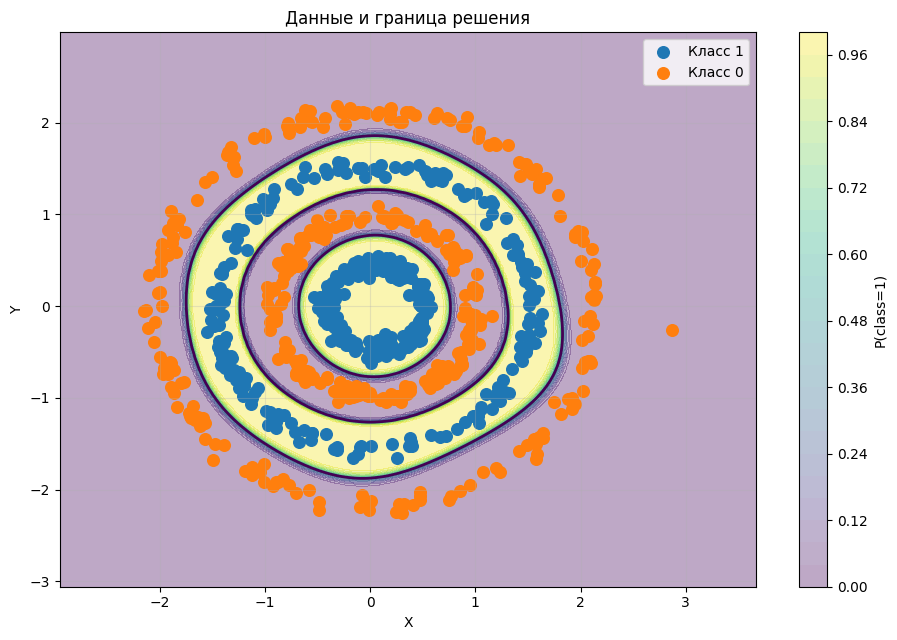

In [32]:
k = 8

model = nn.Sequential(
    nn.Linear(2, k),
    nn.SiLU(),
    nn.Linear(k, k),
    nn.SiLU(),
    nn.Linear(k, k),
    nn.SiLU(),
    nn.Linear(k, k),
    nn.SiLU(),
    nn.Linear(k, k),
    nn.SiLU(),
    nn.Linear(k, 1),
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

step = make_train_step(model, X, y, criterion, optimizer)
print(compute_metrics(model, X, y, criterion))
for i in range(10000):
  step()
print(compute_metrics(model, X, y, criterion))
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0))

Видимо надо искать баланс. Один слой на 50 не обучил модель, 200 тоже не хватило, поэтому прекращаю эксперимент. Три слоя с 6 нейронами отлично обучило модель. 5 слоев с 4, 6 параметрами оказалось недостаточно, как я нашел, нужно минимум 8 параметров, чтобы модель обучилась. При увеличении слов потребовалось больше нейронов. Нужен баланс.


---

## Задание 5 [1,5 балла]

Теперь попробуй провести те же эксперименты на датасете `dataset_zigzag_gap1.csv`.

**Эксперимент 1 [0,5 балла]**: попробуй разные активации ($ReLU$, $SiLU$, $Tanh$) при количестве нейронов на скрытых слоях $<=10$ и числом скрытых слоёв $=2$.

**Эксперимент 2 [0,5 балла]**: выбери функцию активации (не ту, что была в задании 3) и поэкспериментируй с количеством нейронов. Хороший вариант — рассмотреть 2 случая $<10$, 2 случая $>10$. Сравни с экспериментом 1.

**Эксперимент 3 [0,5 балла]**: поэкспериментируй с глубиной нейросети (например 1, 3, 5 слоёв).



In [34]:
X, y = load_csv_dataset("dataset_zigzag_gap1.csv")

X[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

X = torch.tensor(X).to(device)
y = torch.tensor(y).to(device)

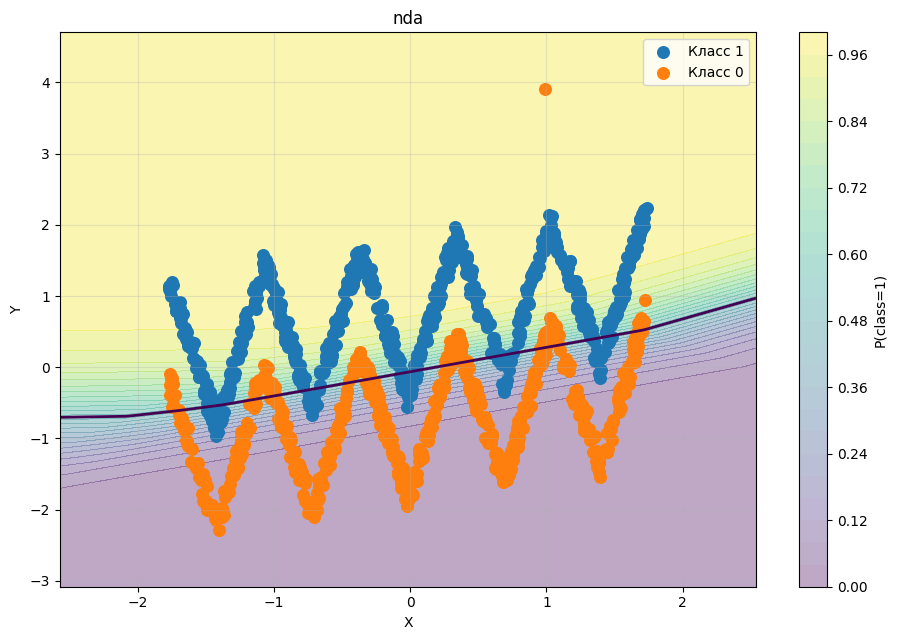

In [45]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

step = make_train_step(model, X, y, criterion, optimizer)
for i in range(10000):
  step()
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

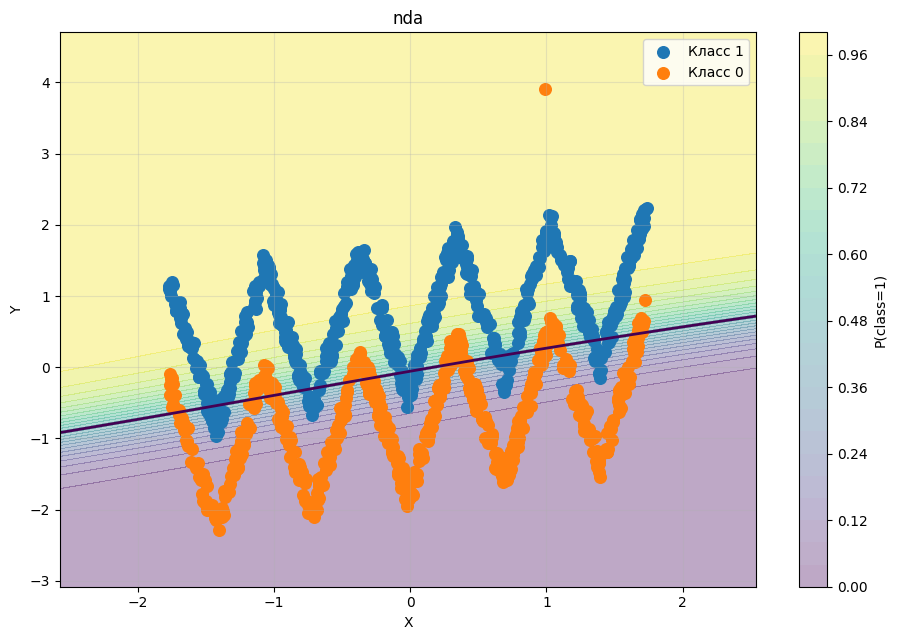

In [46]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.SiLU(),
    nn.Linear(8, 8),
    nn.SiLU(),
    nn.Linear(8, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

step = make_train_step(model, X, y, criterion, optimizer)
for i in range(10000):
  step()
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

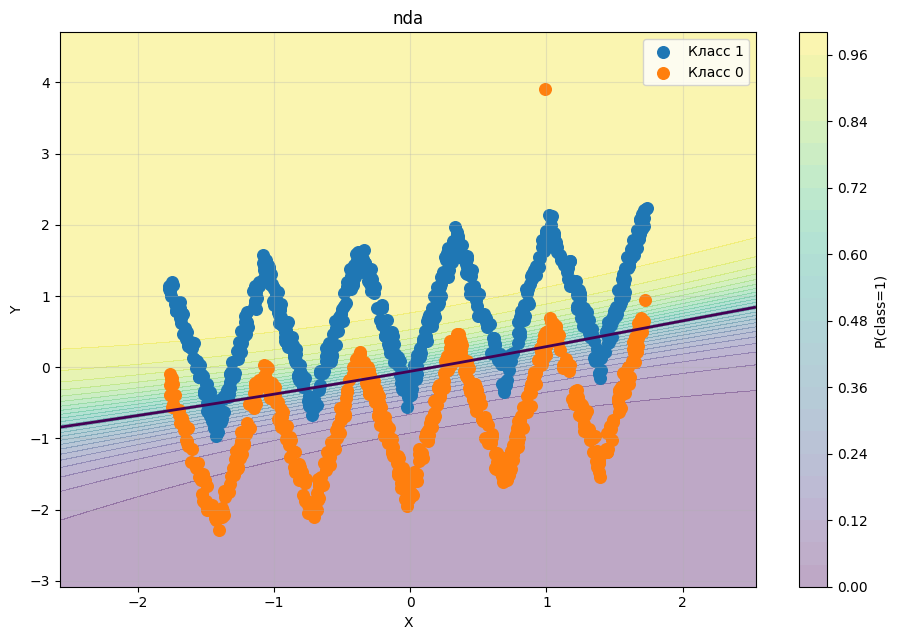

In [47]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.Tanh(),
    nn.Linear(8, 8),
    nn.Tanh(),
    nn.Linear(8, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

step = make_train_step(model, X, y, criterion, optimizer)
for i in range(10000):
  step()
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

Не получилось чот у меня обучить. Перебрал и lr, и колво эпох, всегда плохо.

In [49]:
from tqdm import tqdm

100%|██████████| 10000/10000 [00:19<00:00, 505.44it/s]


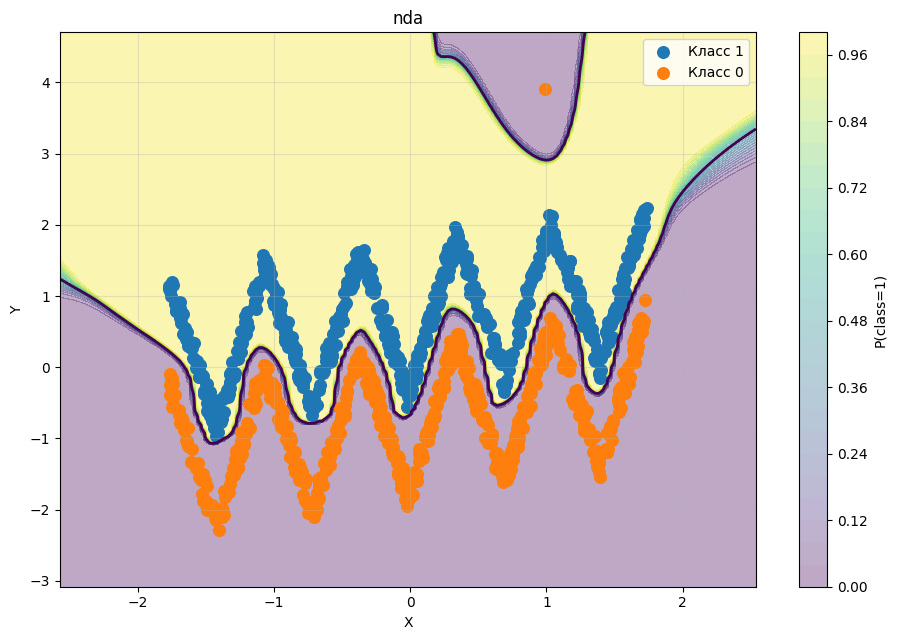

In [53]:
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.Tanh(),
    nn.Linear(16, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

step = make_train_step(model, X, y, criterion, optimizer)
for i in tqdm(range(10000)):
  step()
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

На SGD не дало вообще обучить как бы не перебирал числа. Поменял на адам и увеличил колво нейронов, моментально обучило.

100%|██████████| 5000/5000 [00:10<00:00, 457.68it/s]


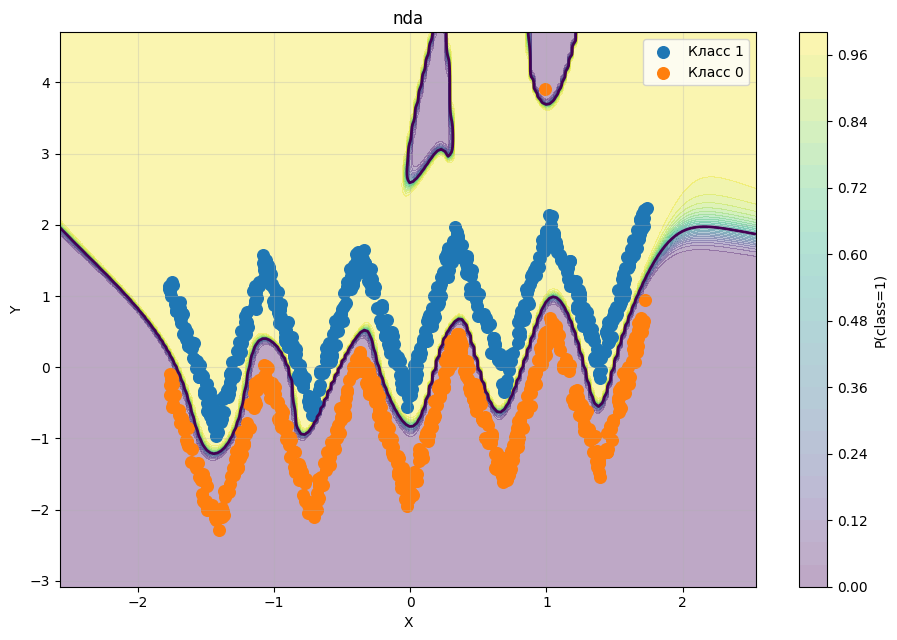

In [56]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.Tanh(),
    nn.Linear(8, 8),
    nn.Tanh(),
    nn.Linear(8, 8),
    nn.Tanh(),
    nn.Linear(8, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

step = make_train_step(model, X, y, criterion, optimizer)
for i in tqdm(range(5000)):
  step()
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

Опираясь на опыт прошлого задания, у меня получилось обучиться, снизив колво параметров и увеличив колво слоев, но если постаивть много слоев, то опять сломается

---

## Задание 6 [1,5 балла]

Проверь, как хорошо обучается на данном датасете глубокая нейросеть с $SiLU$. Сделай выводы **[1 балл]**.

Просмотри все результаты экспериментов ещё раз и подведи итоги **[0,5 балла]**.


100%|██████████| 4000/4000 [00:12<00:00, 311.86it/s]


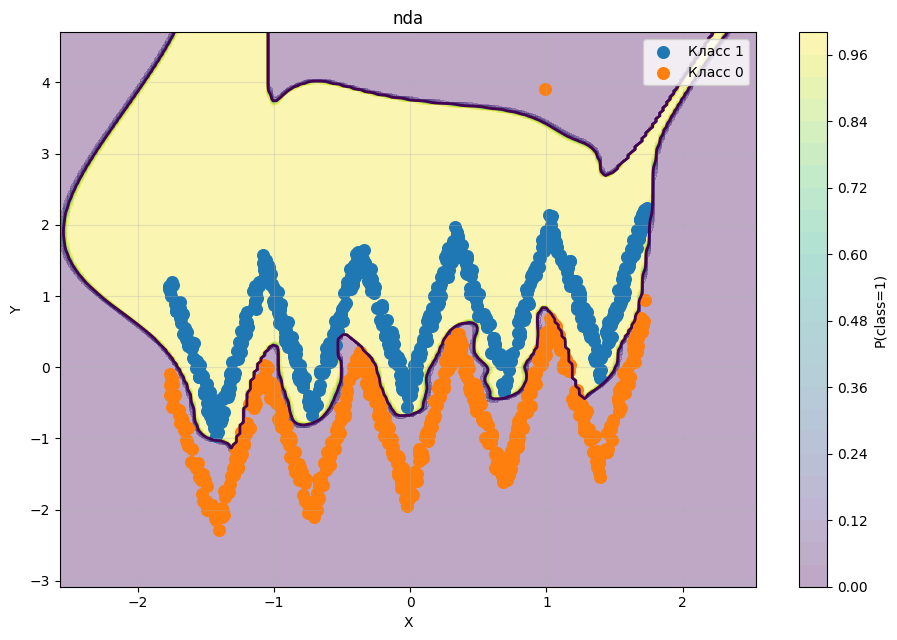

In [58]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.SiLU(),
    nn.Linear(8, 8),
    nn.SiLU(),
    nn.Linear(8, 8),
    nn.SiLU(),
    nn.Linear(8, 8),
    nn.SiLU(),
    nn.Linear(8, 8),
    nn.SiLU(),
    nn.Linear(8, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

step = make_train_step(model, X, y, criterion, optimizer)
for i in tqdm(range(4000)):
  step()
plot_data_and_boundary(model, X, y, X.mean(axis=0), X.std(axis=0), title="nda")

В глубокой можно немного снизить колво итераций, но это уже выглядит хуже, чем если не перебарщивать.

Твои выводы по пункту $i$